# Customer Churn & Retention Engine
## Model Development

### Objective
Build, validate, compare and optimize leakage-safe machine learning models
for customer churn prediction and retention decision-making.

### Workflow
1. Data loading
2. Data validation
3. Train/Validation/Test split
4. Preprocessing pipeline
5. Feature engineering
6. Baseline models
7. Model experimentation
8. Cross-validation
9. Hyperparameter optimization
10. Imbalance handling
11. Feature selection
12. Probability calibration
13. Error analysis
14. Model selection
15. Explainability
16. Threshold optimization
17. Business ROI
18. Final model freeze */

In [10]:
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [11]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
%pip install pyyaml

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df=pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [16]:
#basic validation
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isna().sum().sum())

print("\nDuplicates:", df.duplicated().sum())

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
0

Duplicates: 0


In [17]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)

In [18]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [19]:
X=df.drop(columns=["Churn","customerID"])
y=df["Churn"].map({"No":0,"Yes":1})

In [20]:
X.shape

(7043, 19)

In [21]:
y.shape

(7043,)

In [22]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [23]:
from sklearn.model_selection import train_test_split

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [25]:
y_train.value_counts(normalize="index")*100

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

In [26]:
y_test.value_counts(normalize="index")*100

Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64

In [27]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()

categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical:", numeric_features)
print("\nCategorical:", categorical_features)

Numerical: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# Preprocessing

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [29]:
numeric_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])

In [30]:
from sklearn.preprocessing import OneHotEncoder

In [31]:
categorical_pipeline=Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("encoder",OneHotEncoder(handle_unknown="ignore",drop="first"))])

In [32]:
from sklearn.compose import ColumnTransformer

In [33]:
preprocessor=ColumnTransformer([("num",numeric_pipeline,numeric_features),("cat",categorical_pipeline,categorical_features)])

In [34]:
X_train_processed=preprocessor.fit_transform(X_train)

In [35]:
X_test_processed=preprocessor.transform(X_test)

In [36]:
X_train.shape

(5634, 19)

In [37]:
X_train_processed.shape

(5634, 30)

In [38]:
X_test.shape


(1409, 19)

In [39]:
X_test_processed.shape

(1409, 30)

In [40]:
#pipeline
#Fold1:Train portion-fit preprocessing-fit model-validate,Fold 2....

In [41]:
from sklearn.dummy import DummyClassifier

In [42]:
dummy_pipeline=Pipeline([("preprocessor",preprocessor),("model",DummyClassifier(strategy="most_frequent"))])

In [43]:
dummy_pipeline.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [44]:
y_pred_dummy=dummy_pipeline.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix

In [46]:
print("Accuracy :", accuracy_score(y_test, y_pred_dummy))
print("Precision:", precision_score(y_test, y_pred_dummy,zero_division=0))
print("Recall   :", recall_score(y_test, y_pred_dummy,zero_division=0))
print("F1       :", f1_score(y_test, y_pred_dummy,zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dummy))

Accuracy : 0.7345635202271115
Precision: 0.0
Recall   : 0.0
F1       : 0.0

Confusion Matrix:
[[1035    0]
 [ 374    0]]


# Model Selection

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import(RandomForestClassifier,ExtraTreesClassifier,AdaBoostClassifier,GradientBoostingClassifier,HistGradientBoostingClassifier)
lr_pipeline=Pipeline(["preprocessor",preprocessor]),("model")

In [48]:
models={"Logistic Regression":LogisticRegression(max_iter=1000),
       "KNN":KNeighborsClassifier(),
       "Decision Tree":DecisionTreeClassifier(random_state=42),
       "Random Forest":RandomForestClassifier(random_state=42,n_jobs=-1),
       "Extra Trees":ExtraTreesClassifier(random_state=42,n_jobs=-1),
        "AdaBoost":AdaBoostClassifier(random_state=42),
        "Gradient Boosting":GradientBoostingClassifier(random_state=42),
        "Hist Gradient Boosting":HistGradientBoostingClassifier(random_state=42)}

In [49]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [50]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [51]:
cv

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [52]:
from sklearn.model_selection import cross_validate
def compare_model(model,X,y,cv,scoring):
    pipeline=Pipeline([("preprocessor",preprocessor),("model",model)])
    results=cross_validate(pipeline,X,y,cv=cv,scoring=scoring,n_jobs=-1)
    return{
        "PR-AUC Mean":results["test_pr_auc"].mean(),
        "PR-AUC Std":results["test_pr_auc"].std(),
        "ROC-AUC Mean":results["test_roc_auc"].std(),
        "Precision Mean":results["test_precision"].mean(),
        "Recall Mean":results["test_recall"].mean(),
        "F1 Mean":results["test_f1"].mean(),
        "Accuracy Mean":results["test_accuracy"].mean()
    }

In [53]:
comparision_results={}
for name,model in models.items():
    print(f"Evaluating {name}...")
    comparision_results[name]=compare_model(model,X_train,y_train,cv,scoring)

Evaluating Logistic Regression...
Evaluating KNN...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating AdaBoost...
Evaluating Gradient Boosting...
Evaluating Hist Gradient Boosting...


In [54]:
comparision_df=pd.DataFrame(comparision_results).T
comparision_df

,PR-AUC Mean,PR-AUC Std,ROC-AUC Mean,Precision Mean,Recall Mean,F1 Mean,Accuracy Mean
Logistic Regression,0.661401,0.019233,0.012524,0.654273,0.543813,0.593307,0.802629
KNN,0.516112,0.017208,0.008476,0.569487,0.535786,0.551736,0.769082
Decision Tree,0.380395,0.021375,0.019347,0.491906,0.501672,0.496711,0.730036
Random Forest,0.619182,0.025145,0.012693,0.637178,0.480268,0.547424,0.789140
Extra Trees,0.572166,0.038402,0.014129,0.594747,0.472241,0.526326,0.774408
AdaBoost,0.654190,0.019607,0.013476,0.668691,0.494983,0.567952,0.800144
Gradient Boosting,0.666942,0.019215,0.011902,0.664742,0.517726,0.581486,0.802274
Hist Gradient Boosting,0.652603,0.019234,0.011190,0.642921,0.520401,0.574886,0.795884


In [55]:
from xgboost import XGBClassifier 
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [56]:
models.update({
    "XGBoost":XGBClassifier(random_state=42,eval_metric="logloss"),
    "LightGBM":LGBMClassifier(random_state=42,verbosity=-1),
    "CatBoost":CatBoostClassifier(random_state=42,verbose=0)
})

In [57]:
comparision_results={}
for name,model in models.items():
    print(f"Evaluating {name}...")
    comparision_results[name]=compare_model(model,X_train,y_train,cv,scoring)

Evaluating Logistic Regression...
Evaluating KNN...
Evaluating Decision Tree...
Evaluating Random Forest...
Evaluating Extra Trees...
Evaluating AdaBoost...
Evaluating Gradient Boosting...
Evaluating Hist Gradient Boosting...
Evaluating XGBoost...
Evaluating LightGBM...
Evaluating CatBoost...


In [58]:
comparision_df=pd.DataFrame(comparision_results).T
comparision_df.round(4)

,PR-AUC Mean,PR-AUC Std,ROC-AUC Mean,Precision Mean,Recall Mean,F1 Mean,Accuracy Mean
Logistic Regression,0.6614,0.0192,0.0125,0.6543,0.5438,0.5933,0.8026
KNN,0.5161,0.0172,0.0085,0.5695,0.5358,0.5517,0.7691
Decision Tree,0.3804,0.0214,0.0193,0.4919,0.5017,0.4967,0.7300
Random Forest,0.6192,0.0251,0.0127,0.6372,0.4803,0.5474,0.7891
Extra Trees,0.5722,0.0384,0.0141,0.5947,0.4722,0.5263,0.7744
AdaBoost,0.6542,0.0196,0.0135,0.6687,0.4950,0.5680,0.8001
Gradient Boosting,0.6669,0.0192,0.0119,0.6647,0.5177,0.5815,0.8023
Hist Gradient Boosting,0.6526,0.0192,0.0112,0.6429,0.5204,0.5749,0.7959
XGBoost,0.6201,0.0218,0.0083,0.6212,0.5244,0.5685,0.7888
LightGBM,0.6437,0.0225,0.0123,0.6379,0.5137,0.5689,0.7936


In [59]:
from sklearn.model_selection import RandomizedSearchCV

In [60]:
gb_pipeline=Pipeline([("preprocessor",preprocessor),("model",GradientBoostingClassifier(random_state=42))])

In [61]:
param_distributions={"model__n_estimators":[50,100,150,200,300],
                    "model__learning_rate":[0.01,0.03,0.05,0.1,0.2],
                     "model__max_depth":[2,3,4,5],
                    "model__min_samples_split":[2,5,10,20],
                    "model__min_samples_leaf":[1,2,5,10],
                     "model__subsample":[0.7,0.8,0.9,1.0]
                    }

In [62]:
gb_search=RandomizedSearchCV(estimator=gb_pipeline,
                             param_distributions=param_distributions,
                             n_iter=30,
                             scoring="average_precision",
                             cv=cv,random_state=42,
                             n_jobs=-1,
                             verbose=1)

In [63]:
gb_search.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [64]:
print("best PR-AUC:",gb_search.best_score_)
print("\nBest Parameters")
print(gb_search.best_params_)

best PR-AUC: 0.6701625348886979

Best Parameters
{'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 10, 'model__max_depth': 4, 'model__learning_rate': 0.05}


In [65]:
best_gb=gb_search.best_estimator_

In [66]:
print("Default GB PR_AUC:",comparision_df.loc["Gradient Boosting","PR-AUC Mean"])
print("TunedGB PR-AUC:",gb_search.best_score_)

Default GB PR_AUC: 0.6669415713984627
TunedGB PR-AUC: 0.6701625348886979


In [67]:
improvement=(gb_search.best_score_-comparision_df.loc["Gradient Boosting","PR-AUC Mean"])
print("PR-AUC improvement:",improvement)

PR-AUC improvement: 0.0032209634902352624


In [68]:
lr_pipeline=Pipeline([("preprocessor",preprocessor),("model",LogisticRegression(max_iter=2000,solver="liblinear"))])

In [69]:
lr_params={"model__C":[0.001,0.01,0.1,1,10,100],"model__penalty":["l1","l2"]}

In [70]:
lr_search=RandomizedSearchCV(estimator=lr_pipeline,
                             param_distributions=lr_params,
                             n_iter=12,
                             scoring="average_precision",
                             cv=cv,
                             random_state=42,
                             n_jobs=-1,
                            )
lr_search.fit(X_train,y_train)

,estimator,Pipeline(step...liblinear'))])
,param_distributions,"{'model__C': [0.001, 0.01, ...], 'model__penalty': ['l1', 'l2']}"
,n_iter,12
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [71]:
print("Best LR PR-AUC:",lr_search.best_score_)
print("\nBest Parameters:",lr_search.best_params_)

Best LR PR-AUC: 0.6614604982325749

Best Parameters: {'model__penalty': 'l1', 'model__C': 1}


In [72]:
cat_pipeline=Pipeline([("preprocessor",preprocessor),("model",CatBoostClassifier(random_state=42,verbose=0))])

In [73]:
cat_params={"model__iterations":[100,200,300,500],
            "model__learning_rate":[0.01,0.03,0.05,0.1],
            "model__depth":[4,5,6,7,8],
            "model__l2_leaf_reg":[1,3,5,10],
            "model__subsample":[0.7,0.8,0.9,1.0]
           }

In [74]:
cat_search=RandomizedSearchCV(estimator=cat_pipeline,
                              param_distributions=cat_params,
                              n_iter=25,
                              scoring="average_precision",
                              cv=cv,
                              random_state=42,
                              n_jobs=-1,
                              verbose=1,
                              error_score="raise"
                             )

In [75]:
cat_search.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,Pipeline(step... verbose=0))])
,param_distributions,"{'model__depth': [4, 5, ...], 'model__iterations': [100, 200, ...], 'model__l2_leaf_reg': [1, 3, ...], 'model__learning_rate': [0.01, 0.03, ...], ...}"
,n_iter,25
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,'raise'


In [76]:
#print("Best CatBoost PR-AUC:",cat_search.best_score_)
print("\nBest Parameters:",cat_search.best_params_)


Best Parameters: {'model__subsample': 0.7, 'model__learning_rate': 0.01, 'model__l2_leaf_reg': 3, 'model__iterations': 500, 'model__depth': 5}


In [77]:
lgb_pipeline=Pipeline([("preprocessor",preprocessor),("model",LGBMClassifier(random_state=42,verbosity=-1))])

In [78]:
lgb_params={"model__n_estimators":[100,200,300,500],
            "model__learning_rate":[0.01,0.03,0.05,0.1],
            "model__num_leaves":[15,31,50,70],
            "model__max_depth":[-1,3,5,7,10],
            "model__min_child_samples":[10,20,30,50],
            "model__subsample":[0.7,0.8,0.9,1.0]
           }

In [79]:
lgb_search=RandomizedSearchCV(estimator=lgb_pipeline,
                              param_distributions=lgb_params,
                              n_iter=25,
                              scoring="average_precision",
                              cv=cv,
                              random_state=42,
                              n_jobs=-1,
                              verbose=1
                             )
lgb_search.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,Pipeline(step...rbosity=-1))])
,param_distributions,"{'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [-1, 3, ...], 'model__min_child_samples': [10, 20, ...], 'model__n_estimators': [100, 200, ...], ...}"
,n_iter,25
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [80]:
print("Best LightGBN PR-AUC:",lgb_search.best_score_)
print("\nBest Parameters:",lgb_search.best_params_)

Best LightGBN PR-AUC: 0.6652178543549626

Best Parameters: {'model__subsample': 0.8, 'model__num_leaves': 31, 'model__n_estimators': 200, 'model__min_child_samples': 30, 'model__max_depth': 3, 'model__learning_rate': 0.03}


In [81]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

In [82]:
xgb_params = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5, 6],
    "model__min_child_weight": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [83]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [84]:
print("Best XGBoost PR-AUC:", xgb_search.best_score_)
print("\nBest Parameters:")
print(xgb_search.best_params_)

Best XGBoost PR-AUC: 0.6690446852313011

Best Parameters:
{'model__subsample': 0.8, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}


In [85]:
tuned_results = {
    "Logistic Regression": lr_search.best_score_,
    "Gradient Boosting": gb_search.best_score_,
    "CatBoost": cat_search.best_score_,
    "LightGBM": lgb_search.best_score_,
    "XGBoost": xgb_search.best_score_
}

tuned_df = (
    pd.DataFrame.from_dict(
        tuned_results,
        orient="index",
        columns=["CV_PR_AUC"]
    )
    .sort_values("CV_PR_AUC", ascending=False)
)

tuned_df.round(4)

,CV_PR_AUC
CatBoost,0.6703
Gradient Boosting,0.6702
XGBoost,0.6690
LightGBM,0.6652
Logistic Regression,0.6615


# Best Model After Tuning

In [86]:
lr_search
gb_search
cat_search
lgb_search
xgb_search

,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,n_iter,25
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [87]:
best_models = {
    "Logistic Regression": lr_search.best_estimator_,
    "Gradient Boosting": gb_search.best_estimator_,
    "CatBoost": cat_search.best_estimator_,
    "LightGBM": lgb_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

In [88]:
full_scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "accuracy": "accuracy"
}

In [89]:
tuned_cv_results = {}

for name, model in best_models.items():
    print(f"Evaluating {name}...")
    
    results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=full_scoring,
        n_jobs=-1
    )
    
    tuned_cv_results[name] = {
        metric: results[f"test_{metric}"].mean()
        for metric in full_scoring
    }
    
    tuned_cv_results[name].update({
        "pr_auc_std": results["test_pr_auc"].std(),
        "roc_auc_std": results["test_roc_auc"].std(),
        "f1_std": results["test_f1"].std()
    })

Evaluating Logistic Regression...
Evaluating Gradient Boosting...
Evaluating CatBoost...
Evaluating LightGBM...
Evaluating XGBoost...


In [90]:
finalist_df = pd.DataFrame(tuned_cv_results).T
finalist_df.round(4)

,pr_auc,roc_auc,precision,recall,f1,accuracy,pr_auc_std,roc_auc_std,f1_std
Logistic Regression,0.6615,0.8459,0.6531,0.5431,0.5924,0.8021,0.0189,0.0124,0.0297
Gradient Boosting,0.6702,0.8500,0.6768,0.5177,0.5865,0.8064,0.0191,0.0117,0.0245
CatBoost,0.6703,0.8496,0.6797,0.5110,0.5830,0.8060,0.0207,0.0128,0.0193
LightGBM,0.6652,0.8484,0.6746,0.5084,0.5794,0.8042,0.0195,0.0119,0.0191
XGBoost,0.6690,0.8490,0.6683,0.5191,0.5839,0.8037,0.0181,0.0114,0.0203


# Imbalance Handling

In [91]:
lr_weighted = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        class_weight="balanced"
    ))
])

In [92]:
weighted_lr_results = cross_validate(
    lr_weighted,
    X_train,
    y_train,
    cv=cv,
    scoring=full_scoring,
    n_jobs=-1
)

In [93]:
weighted_lr_summary = {
    metric: weighted_lr_results[f"test_{metric}"].mean()
    for metric in full_scoring
}

weighted_lr_summary

{'pr_auc': np.float64(0.6599891795035049),
 'roc_auc': np.float64(0.8458678892548324),
 'precision': np.float64(0.5175301476225501),
 'recall': np.float64(0.8020066889632107),
 'f1': np.float64(0.6289126346219093),
 'accuracy': np.float64(0.7490252970444491)}

In [94]:
print("Normal LR PR-AUC:",
      tuned_cv_results["Logistic Regression"]["pr_auc"])

print("Weighted LR PR-AUC:",
      weighted_lr_summary["pr_auc"])

Normal LR PR-AUC: 0.6614549586896777
Weighted LR PR-AUC: 0.6599891795035049


In [95]:
print("Normal LR Recall:",
      tuned_cv_results["Logistic Regression"]["recall"])

print("Weighted LR Recall:",
      weighted_lr_summary["recall"])

Normal LR Recall: 0.5431438127090301
Weighted LR Recall: 0.8020066889632107


# Random Oversampling

In [96]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
lr_oversampled = ImbPipeline([
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear"
    ))
])

In [97]:
oversample_results = cross_validate(
    lr_oversampled,
    X_train,
    y_train,
    cv=cv,
    scoring=full_scoring,
    n_jobs=-1
)

In [98]:
oversample_summary = {
    metric: oversample_results[f"test_{metric}"].mean()
    for metric in full_scoring
}

oversample_summary

{'pr_auc': np.float64(0.6588175328509408),
 'roc_auc': np.float64(0.8456782408599965),
 'precision': np.float64(0.5159312138353263),
 'recall': np.float64(0.8013377926421406),
 'f1': np.float64(0.6275073708874306),
 'accuracy': np.float64(0.747783218623769)}

# Smote

In [99]:
from imblearn.over_sampling import SMOTE
lr_smote = ImbPipeline([
    ("preprocessor", preprocessor),
    ("sampler", SMOTE(random_state=42)),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear"
    ))
])

In [100]:
smote_results = cross_validate(
    lr_smote,
    X_train,
    y_train,
    cv=cv,
    scoring=full_scoring,
    n_jobs=-1
)

In [101]:
smote_summary = {
    metric: smote_results[f"test_{metric}"].mean()
    for metric in full_scoring
}

smote_summary

{'pr_auc': np.float64(0.6582321866741483),
 'roc_auc': np.float64(0.844614980985537),
 'precision': np.float64(0.5256690069264703),
 'recall': np.float64(0.7892976588628763),
 'f1': np.float64(0.6308610090866584),
 'accuracy': np.float64(0.7550621669626999)}

In [102]:
imbalance_comparison = pd.DataFrame({
    "Normal LR": tuned_cv_results["Logistic Regression"],
    "Class Weighted LR": weighted_lr_summary,
    "Random Oversampling": oversample_summary,
    "SMOTE": smote_summary
}).T

imbalance_comparison.round(4)

,pr_auc,roc_auc,precision,recall,f1,accuracy,pr_auc_std,roc_auc_std,f1_std
Normal LR,0.6615,0.8459,0.6531,0.5431,0.5924,0.8021,0.0189,0.0124,0.0297
Class Weighted LR,0.6600,0.8459,0.5175,0.8020,0.6289,0.7490,NaN,NaN,NaN
Random Oversampling,0.6588,0.8457,0.5159,0.8013,0.6275,0.7478,NaN,NaN,NaN
SMOTE,0.6582,0.8446,0.5257,0.7893,0.6309,0.7551,NaN,NaN,NaN


# Feature Selection

In [103]:
from sklearn.feature_selection import SelectFromModel
lr_l1_selection = Pipeline([
    ("preprocessor", preprocessor),
    ("selector", SelectFromModel(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=2000
        )
    )),
    ("model", LogisticRegression(
        max_iter=2000,
        solver="liblinear"
    ))
])

In [104]:
selection_results = cross_validate(
    lr_l1_selection,
    X_train,
    y_train,
    cv=cv,
    scoring=full_scoring,
    n_jobs=-1
)

In [105]:
selection_summary = {
    metric: selection_results[f"test_{metric}"].mean()
    for metric in full_scoring
}

selection_summary

{'pr_auc': np.float64(0.661390394837716),
 'roc_auc': np.float64(0.8459131168974752),
 'precision': np.float64(0.653307076894956),
 'recall': np.float64(0.5438127090301003),
 'f1': np.float64(0.5928837579337298),
 'accuracy': np.float64(0.8022737552817094)}

In [106]:
print("All features PR-AUC:",
      tuned_cv_results["Logistic Regression"]["pr_auc"])

print("Selected features PR-AUC:",
      selection_summary["pr_auc"])

All features PR-AUC: 0.6614549586896777
Selected features PR-AUC: 0.661390394837716


# Permutation importance

In [107]:
best_model = gb_search.best_estimator_

best_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    best_model,
    X_train,
    y_train,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [109]:
feature_names = X_train.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
})

importance_df = importance_df.sort_values(
    "importance_mean",
    ascending=False
)

importance_df.head(15)

,feature,importance_mean,importance_std
4,tenure,0.139041,0.006747
7,InternetService,0.101478,0.009371
18,TotalCharges,0.058478,0.004042
14,Contract,0.046307,0.004370
17,MonthlyCharges,0.043584,0.003541
6,MultipleLines,0.017215,0.001230
15,PaperlessBilling,0.017122,0.001501
16,PaymentMethod,0.015281,0.001664
8,OnlineSecurity,0.011511,0.002430
11,TechSupport,0.007930,0.001110


In [110]:
best_model = gb_search.best_estimator_

In [111]:
from sklearn.model_selection import cross_val_predict

y_prob_uncalibrated = cross_val_predict(
    best_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [112]:
y_prob_uncalibrated[:10]

array([0.30295914, 0.288596  , 0.03390346, 0.03976906, 0.60228136,
       0.02861345, 0.29474886, 0.13406559, 0.03518339, 0.07193669])

In [113]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_train,
    y_prob_uncalibrated,
    n_bins=10,
    strategy="quantile"
)

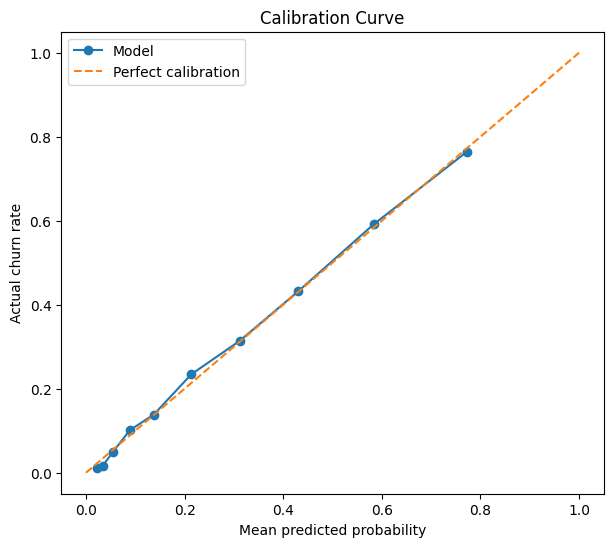

In [114]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Model"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Actual churn rate")
plt.title("Calibration Curve")
plt.legend()
plt.show()

In [115]:
from sklearn.metrics import brier_score_loss

brier_uncalibrated = brier_score_loss(
    y_train,
    y_prob_uncalibrated
)

print("Uncalibrated Brier Score:", brier_uncalibrated)

Uncalibrated Brier Score: 0.13343166663279718


In [116]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_sigmoid = CalibratedClassifierCV(
    estimator=best_model,
    method="sigmoid",
    cv=cv
)

calibrated_sigmoid.fit(X_train, y_train)

,estimator,Pipeline(step...sample=0.7))])
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [117]:
y_prob_sigmoid = calibrated_sigmoid.predict_proba(
    X_train
)[:, 1]

In [118]:
brier_sigmoid = brier_score_loss(
    y_train,
    y_prob_sigmoid
)

print("Sigmoid Brier Score:", brier_sigmoid)

Sigmoid Brier Score: 0.11935630707700622


In [119]:
calibrated_isotonic = CalibratedClassifierCV(
    estimator=best_model,
    method="isotonic",
    cv=cv
)

calibrated_isotonic.fit(X_train, y_train)

,estimator,Pipeline(step...sample=0.7))])
,method,'isotonic'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [120]:
y_prob_isotonic = calibrated_isotonic.predict_proba(
    X_train
)[:, 1]

brier_isotonic = brier_score_loss(
    y_train,
    y_prob_isotonic
)

print("Isotonic Brier Score:", brier_isotonic)

Isotonic Brier Score: 0.11848506088404438


In [121]:
calibration_results = pd.DataFrame({
    "Model": [
        "Uncalibrated",
        "Sigmoid",
        "Isotonic"
    ],
    "Brier Score": [
        brier_uncalibrated,
        brier_sigmoid,
        brier_isotonic
    ]
})

calibration_results

,Model,Brier Score
0,Uncalibrated,0.133432
1,Sigmoid,0.119356
2,Isotonic,0.118485


In [122]:
finalist = gb_search.best_estimator_

finalist.fit(X_train, y_train)

y_prob = finalist.predict_proba(X_train)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

In [123]:
error_df=X_train.copy()
error_df["actual"] = y_train.values
error_df["probability"] = y_prob
error_df["predicted"] = y_pred

false_positives = error_df[
    (error_df["actual"] == 0) &
    (error_df["predicted"] == 1)
]

false_negatives = error_df[
    (error_df["actual"] == 1) &
    (error_df["predicted"] == 0)
]

In [124]:
print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

False Positives: 308
False Negatives: 656


In [125]:
false_negatives[
    ["tenure", "MonthlyCharges", "Contract", "PaymentMethod"]
].describe(include="all")

,tenure,MonthlyCharges,Contract,PaymentMethod
count,656.000000,656.000000,656,656
unique,NaN,NaN,3,4
top,NaN,NaN,Month-to-month,Electronic check
freq,NaN,NaN,488,243
mean,29.760671,68.466921,NaN,NaN
std,22.169349,28.880239,NaN,NaN
min,1.000000,18.850000,NaN,NaN
25%,9.000000,45.800000,NaN,NaN
50%,27.000000,73.850000,NaN,NaN
75%,49.000000,94.137500,NaN,NaN


In [126]:
false_positives[
    ["tenure", "MonthlyCharges", "Contract", "PaymentMethod"]
].describe(include="all")

,tenure,MonthlyCharges,Contract,PaymentMethod
count,308.000000,308.000000,308,308
unique,NaN,NaN,2,4
top,NaN,NaN,Month-to-month,Electronic check
freq,NaN,NaN,307,229
mean,10.659091,78.891234,NaN,NaN
std,11.674634,18.924280,NaN,NaN
min,1.000000,20.050000,NaN,NaN
25%,2.000000,70.575000,NaN,NaN
50%,6.500000,80.700000,NaN,NaN
75%,15.000000,94.012500,NaN,NaN


In [127]:
final_comparison = finalist_df.copy()

final_comparison = final_comparison.sort_values(
    "pr_auc",
    ascending=False
)

final_comparison.round(4)

,pr_auc,roc_auc,precision,recall,f1,accuracy,pr_auc_std,roc_auc_std,f1_std
CatBoost,0.6703,0.8496,0.6797,0.5110,0.5830,0.8060,0.0207,0.0128,0.0193
Gradient Boosting,0.6702,0.8500,0.6768,0.5177,0.5865,0.8064,0.0191,0.0117,0.0245
XGBoost,0.6690,0.8490,0.6683,0.5191,0.5839,0.8037,0.0181,0.0114,0.0203
LightGBM,0.6652,0.8484,0.6746,0.5084,0.5794,0.8042,0.0195,0.0119,0.0191
Logistic Regression,0.6615,0.8459,0.6531,0.5431,0.5924,0.8021,0.0189,0.0124,0.0297


In [128]:
final_model=gb_search.best_estimator_

final_model.fit(X_train,y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [129]:
X_train_processed = final_model.named_steps[
    "preprocessor"
].transform(X_train)

feature_names = final_model.named_steps[
    "preprocessor"
].get_feature_names_out()

In [130]:
import shap

tree_model = final_model.named_steps["model"]

explainer = shap.TreeExplainer(tree_model)
shap_values = explainer.shap_values(X_train_processed)

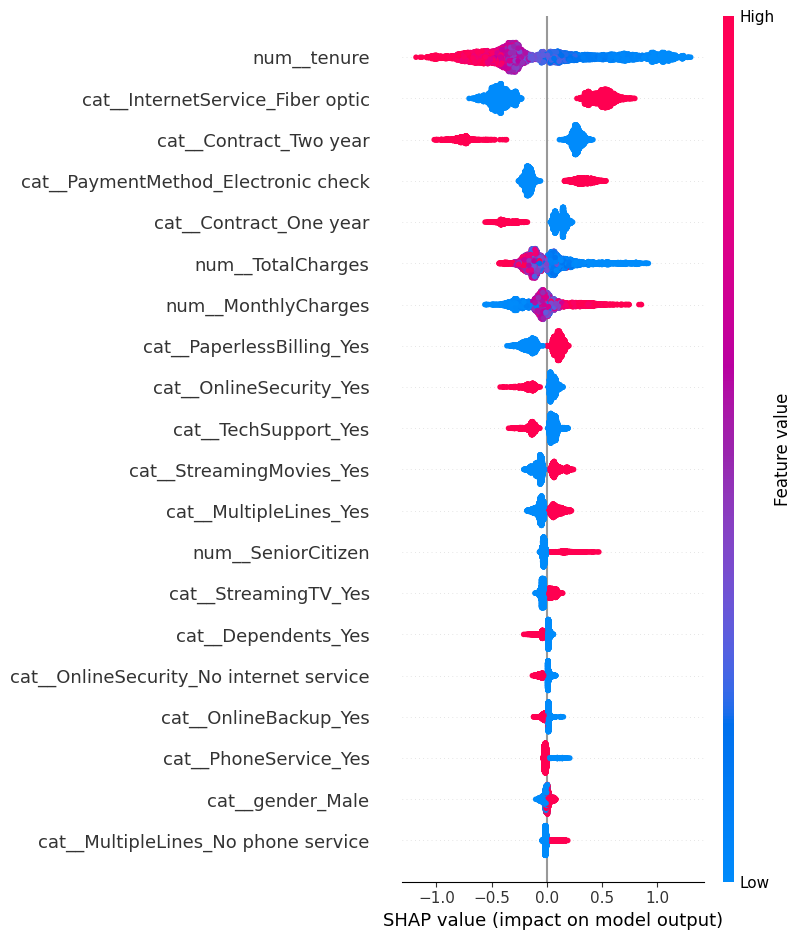

In [131]:
shap.summary_plot(
    shap_values,
    X_train_processed,
    feature_names=feature_names
)

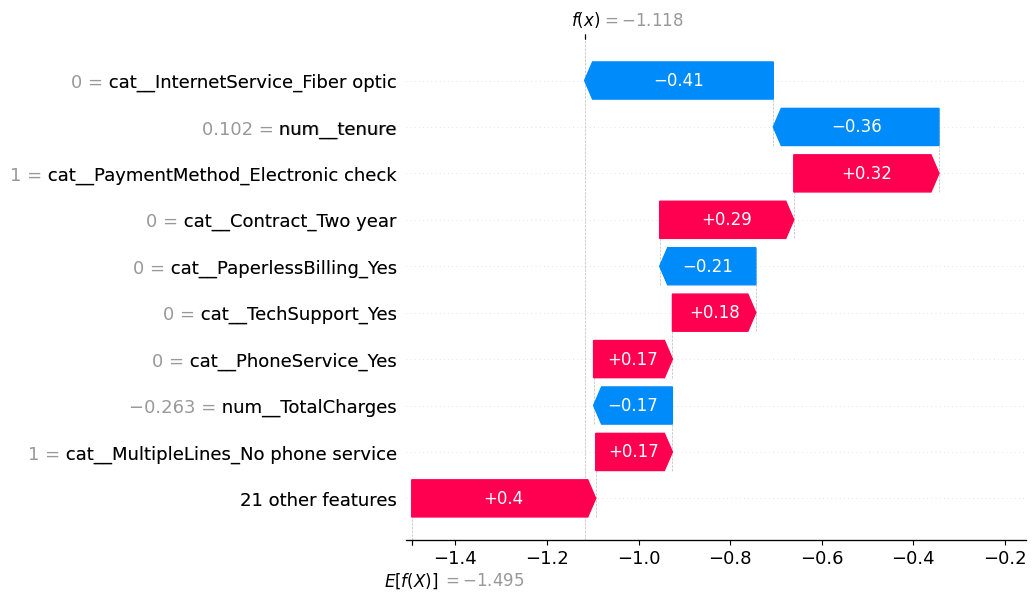

In [132]:
customer_idx = 0

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[customer_idx],
        base_values=explainer.expected_value,
        data=X_train_processed[customer_idx],
        feature_names=feature_names
    )
)

In [133]:
from sklearn.calibration import CalibratedClassifierCV

In [134]:
calibrated_sigmoid = CalibratedClassifierCV(
    estimator=final_model,
    method="sigmoid",
    cv=cv
)

calibrated_sigmoid.fit(X_train, y_train)

,estimator,Pipeline(step...sample=0.7))])
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [135]:
calibrated_isotonic.fitcalibrated_isotonic = CalibratedClassifierCV(
    estimator=final_model,
    method="isotonic",
    cv=cv
)

calibrated_isotonic.fit(X_train, y_train)

,estimator,Pipeline(step...sample=0.7))])
,method,'isotonic'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [136]:
from sklearn.model_selection import cross_val_predict

prob_sigmoid = cross_val_predict(
    calibrated_sigmoid,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

prob_isotonic = cross_val_predict(
    calibrated_isotonic,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [137]:
from sklearn.metrics import brier_score_loss

print(
    "Sigmoid Brier:",
    brier_score_loss(y_train, prob_sigmoid)
)

print(
    "Isotonic Brier:",
    brier_score_loss(y_train, prob_isotonic)
)

Sigmoid Brier: 0.13366533356859955
Isotonic Brier: 0.13383675328899008


In [138]:
calibrated_model = calibrated_sigmoid

calibrated_model.fit(X_train, y_train)

y_prob = calibrated_model.predict_proba(X_train)[:, 1]

In [139]:
from sklearn.metrics import confusion_matrix

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

threshold_results = []

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train,
        y_pred
    ).ravel()

    threshold_results.append({
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "customers_targeted": tp + fp,
        "precision": tp / (tp + fp) if (tp + fp) > 0 else 0,
        "recall": tp / (tp + fn) if (tp + fn) > 0 else 0,
        "specificity": tn / (tn + fp) if (tn + fp) > 0 else 0
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,threshold,TN,FP,FN,TP,customers_targeted,precision,recall,specificity
0,0.2,2856,1283,162,1333,2616,0.5096,0.8916,0.6900
1,0.3,3308,831,306,1189,2020,0.5886,0.7953,0.7992
2,0.4,3633,506,480,1015,1521,0.6673,0.6789,0.8777
3,0.5,3815,324,637,858,1182,0.7259,0.5739,0.9217
4,0.6,3961,178,853,642,820,0.7829,0.4294,0.9570
5,0.7,4071,68,1063,432,500,0.8640,0.2890,0.9836
6,0.8,4123,16,1284,211,227,0.9295,0.1411,0.9961


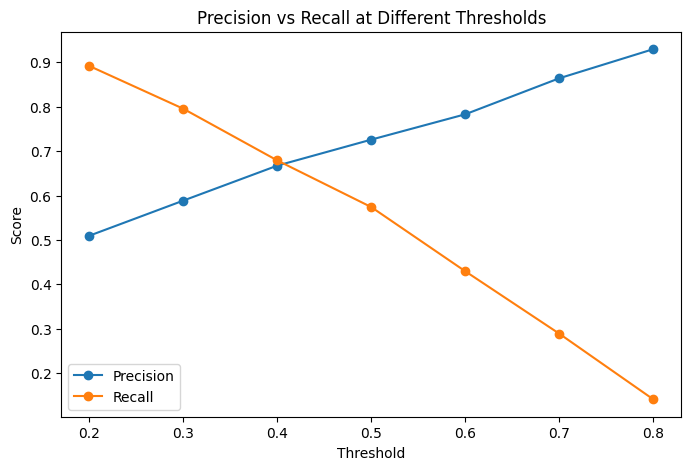

In [140]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall at Different Thresholds")
plt.legend()
plt.show()

In [141]:
campaign_cost = 50
retention_cost = 200
success_rate = 0.30
revenue_at_risk = 2000

In [142]:
roi_results = []

for _, row in threshold_df.iterrows():

    tp = row["TP"]
    fp = row["FP"]
    fn = row["FN"]

    customers_targeted = tp + fp

    campaign_expense = customers_targeted * campaign_cost

    retention_expense = tp * retention_cost

    revenue_protected = (
        tp
        * success_rate
        * revenue_at_risk
    )

    net_benefit = (
        revenue_protected
        - campaign_expense
        - retention_expense
    )

    roi = (
        net_benefit / (campaign_expense + retention_expense)
    ) * 100 if (campaign_expense + retention_expense) > 0 else 0

    roi_results.append({
        "threshold": row["threshold"],
        "customers_targeted": customers_targeted,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "campaign_cost": campaign_expense,
        "retention_cost": retention_expense,
        "revenue_protected": revenue_protected,
        "net_benefit": net_benefit,
        "ROI_percent": roi
    })

roi_df = pd.DataFrame(roi_results)

roi_df.round(2)

,threshold,customers_targeted,TP,FP,FN,campaign_cost,retention_cost,revenue_protected,net_benefit,ROI_percent
0,0.2,2616.0,1333.0,1283.0,162.0,130800.0,266600.0,799800.0,402400.0,101.26
1,0.3,2020.0,1189.0,831.0,306.0,101000.0,237800.0,713400.0,374600.0,110.57
2,0.4,1521.0,1015.0,506.0,480.0,76050.0,203000.0,609000.0,329950.0,118.24
3,0.5,1182.0,858.0,324.0,637.0,59100.0,171600.0,514800.0,284100.0,123.15
4,0.6,820.0,642.0,178.0,853.0,41000.0,128400.0,385200.0,215800.0,127.39
5,0.7,500.0,432.0,68.0,1063.0,25000.0,86400.0,259200.0,147800.0,132.68
6,0.8,227.0,211.0,16.0,1284.0,11350.0,42200.0,126600.0,73050.0,136.41


In [143]:
roi_df.sort_values(
    "net_benefit",
    ascending=False
)

,threshold,customers_targeted,TP,FP,FN,campaign_cost,retention_cost,revenue_protected,net_benefit,ROI_percent
0,0.2,2616.0,1333.0,1283.0,162.0,130800.0,266600.0,799800.0,402400.0,101.258178
1,0.3,2020.0,1189.0,831.0,306.0,101000.0,237800.0,713400.0,374600.0,110.566706
2,0.4,1521.0,1015.0,506.0,480.0,76050.0,203000.0,609000.0,329950.0,118.240459
3,0.5,1182.0,858.0,324.0,637.0,59100.0,171600.0,514800.0,284100.0,123.146944
4,0.6,820.0,642.0,178.0,853.0,41000.0,128400.0,385200.0,215800.0,127.390791
5,0.7,500.0,432.0,68.0,1063.0,25000.0,86400.0,259200.0,147800.0,132.675045
6,0.8,227.0,211.0,16.0,1284.0,11350.0,42200.0,126600.0,73050.0,136.414566


In [144]:
roi_df.sort_values(
    "ROI_percent",
    ascending=False
)

,threshold,customers_targeted,TP,FP,FN,campaign_cost,retention_cost,revenue_protected,net_benefit,ROI_percent
6,0.8,227.0,211.0,16.0,1284.0,11350.0,42200.0,126600.0,73050.0,136.414566
5,0.7,500.0,432.0,68.0,1063.0,25000.0,86400.0,259200.0,147800.0,132.675045
4,0.6,820.0,642.0,178.0,853.0,41000.0,128400.0,385200.0,215800.0,127.390791
3,0.5,1182.0,858.0,324.0,637.0,59100.0,171600.0,514800.0,284100.0,123.146944
2,0.4,1521.0,1015.0,506.0,480.0,76050.0,203000.0,609000.0,329950.0,118.240459
1,0.3,2020.0,1189.0,831.0,306.0,101000.0,237800.0,713400.0,374600.0,110.566706
0,0.2,2616.0,1333.0,1283.0,162.0,130800.0,266600.0,799800.0,402400.0,101.258178


In [145]:
best_threshold = roi_df.loc[
    roi_df["net_benefit"].idxmax(),
    "threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.2


In [146]:
best_roi_threshold = roi_df.loc[
    roi_df["ROI_percent"].idxmax(),
    "threshold"
]

print("Best ROI threshold:", best_roi_threshold)

Best ROI threshold: 0.8


In [147]:
success_rates = [0.20, 0.30, 0.40, 0.50]

sensitivity_results = []

for rate in success_rates:

    for _, row in threshold_df.iterrows():

        tp = row["TP"]
        customers_targeted = row["TP"] + row["FP"]

        campaign_expense = customers_targeted * campaign_cost
        retention_expense = tp * retention_cost

        revenue_protected = (
            tp * rate * revenue_at_risk
        )

        net_benefit = (
            revenue_protected
            - campaign_expense
            - retention_expense
        )

        sensitivity_results.append({
            "success_rate": rate,
            "threshold": row["threshold"],
            "net_benefit": net_benefit
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

In [148]:
best_by_scenario = (
    sensitivity_df
    .loc[
        sensitivity_df.groupby("success_rate")["net_benefit"]
        .idxmax()
    ]
)

best_by_scenario

,success_rate,threshold,net_benefit
1,0.2,0.3,136800.0
7,0.3,0.2,402400.0
14,0.4,0.2,669000.0
21,0.5,0.2,935600.0


In [149]:
risk_df = pd.DataFrame({
    "actual": y_train,
    "churn_probability": y_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

In [150]:
risk_summary = (
    risk_df
    .groupby("risk_level", observed=False)
    .agg(
        customers=("actual", "count"),
        actual_churners=("actual", "sum"),
        actual_churn_rate=("actual", "mean"),
        avg_predicted_probability=("churn_probability", "mean")
    )
)

risk_summary

,customers,actual_churners,actual_churn_rate,avg_predicted_probability
risk_level,,,,
Low,3614,306,0.084671,0.102672
Medium,1200,547,0.455833,0.436844
High,820,642,0.782927,0.734313


In [151]:
final_model=calibrated_sigmoid

In [152]:
final_model.fit(X_train,y_train)

,estimator,Pipeline(step...sample=0.7))])
,method,'sigmoid'
,cv,StratifiedKFo... shuffle=True)
,n_jobs,None
,ensemble,'auto'
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


In [153]:
y_test_prob = final_model.predict_proba(X_test)[:, 1]

y_test_pred = (
    y_test_prob >= best_threshold
).astype(int)

In [154]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss
)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred
).ravel()

final_test_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob),
    "PR_AUC": average_precision_score(y_test, y_test_prob),
    "Brier_Score": brier_score_loss(y_test, y_test_prob),
    "Specificity": tn / (tn + fp)
}

pd.Series(final_test_results).round(4)

Accuracy       0.7197
Precision      0.4841
Recall         0.8529
F1             0.6176
ROC_AUC        0.8476
PR_AUC         0.6638
Brier_Score    0.1349
Specificity    0.6715
dtype: float64

In [155]:
print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 695
FP: 340
FN: 55
TP: 319


In [156]:
import os
os.chdir(r"C:\Users\dell\customer-churn-retention-engine")
print(os.getcwd())

C:\Users\dell\customer-churn-retention-engine


In [157]:
import joblib

joblib.dump(
    final_model,
    "models/churn_model.joblib"
)

['models/churn_model.joblib']

In [158]:
print(os.getcwd())

C:\Users\dell\customer-churn-retention-engine


In [159]:
!python -m pytest tests/test_roi.py

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0
rootdir: C:\Users\dell\customer-churn-retention-engine
plugins: anyio-4.13.0
collected 1 item

tests\test_roi.py .                                                      [100%]

============================== 1 passed in 0.04s ==============================


In [160]:
 !python -m pytest tests/test_predictor.py

============================= test session starts =============================

ERROR: file or directory not found: tests/test_predictor.py




platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0
rootdir: C:\Users\dell\customer-churn-retention-engine
plugins: anyio-4.13.0
collected 0 items

============================ no tests ran in 0.02s ============================


In [161]:
print(os.getcwd())

C:\Users\dell\customer-churn-retention-engine


In [162]:
from src.config import load_config

config = load_config()

config

{'model': 'path:models/churn_model.joblib',
 'business': {'campaign_cost': 50,
  'retention_cost': 200,
  'success_rate': 0.3,
  'revenue_at_risk': 2000,
  'threshold': 0.5}}

In [163]:
print(os.getcwd())

C:\Users\dell\customer-churn-retention-engine


In [164]:
from src.config import load_config
config = load_config()
print(config)

{'model': 'path:models/churn_model.joblib', 'business': {'campaign_cost': 50, 'retention_cost': 200, 'success_rate': 0.3, 'revenue_at_risk': 2000, 'threshold': 0.5}}


# validate columns

In [171]:
import importlib
import src.validation.input_validator as iv

importlib.reload(iv)

validate_input = iv.validate_input

In [172]:
from src.validation.input_validator import validate_input

# Take one real customer from your existing dataframe
customer = df.iloc[[0]].copy()

validate_input(customer)

print("Input validation passed ")

Input validation passed 


In [173]:
bad_customer = customer.drop(columns=["tenure"])

validate_input(bad_customer)

ValueError: Missing required columns: {'tenure'}

In [174]:
from src.validation.input_validator import validate_input

customer = df.drop(columns=["Churn"]).iloc[[0]].copy()

validate_input(customer)

print("Validation passed")

Validation passed


In [175]:
bad_customer = customer.drop(columns=["Contract"])

validate_input(bad_customer)

ValueError: Missing required columns: {'Contract'}

In [176]:
import importlib
import src.validation.input_validator as iv

importlib.reload(iv)

validate_input = iv.validate_input

In [177]:
bad_customer = customer.drop(columns=["Contract"])

validate_input(bad_customer)

ValueError: Missing required columns: {'Contract'}

# Validating Values

In [198]:
import importlib
import src.validation.input_validator as iv

importlib.reload(iv)

validate_input = iv.validate_input

In [199]:
bad_customer = customer.copy()

bad_customer["Contract"] = "Random Contract"

validate_input(bad_customer)

SeniorCitizen int64
tenure int64
MonthlyCharges float64
TotalCharges float64


ValueError: Invalid values in Contract: {'Random Contract'}

In [201]:
import importlib
import src.validation.input_validator as iv

importlib.reload(iv)

validate_input = iv.validate_input

In [202]:
valid_customer = df.drop(columns=["Churn"]).iloc[[0]].copy()

validate_input(valid_customer)

print("All validation checks passed")

SeniorCitizen int64
tenure int64
MonthlyCharges float64
TotalCharges float64
All validation checks passed


In [206]:
bad_customer = valid_customer.copy()

bad_customer["tenure"] = None

validate_input(bad_customer)

SeniorCitizen int64
tenure object


ValueError: tenure must be numeric.

In [218]:
import src.prediction.predictor as p
print(dir(p))

['ChurnPredictor', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'joblib', 'validate_input']


In [221]:
predictor=p.ChurnPredictor("models/churn_model.joblib")
valid_customer = df.drop(columns=["Churn"]).iloc[[0]].copy()

result = predictor.predict(
    valid_customer,
    threshold=config["business"]["threshold"]
)

print(result)

SeniorCitizen int64
tenure int64
MonthlyCharges float64
TotalCharges float64
{'churn_probability': 0.6719160116905456, 'risk_level': 'High', 'recommended_action': 'Retention intervention', 'business_priority': 'High'}
